# AIA Supervisor Agent — Interactive Notebook

This notebook is the interactive version of `agent_code.py`. It implements the full Supervisor Agent with:

**6 LangGraph Nodes:**
1. `classify_intent` — Interprets user question intent
2. `clarify_or_disambiguate` — Handles ambiguous queries (optional)
3. `resolve_assets_with_context_index` — Discovers data assets via Vector Search
4. `route_to_genie` — Text-to-SQL via Genie Space
5. `route_to_multi_tool` — Vector Search RAG over policy documents
6. `compose_answer` — Synthesizes final response

**Enhancements:**
- P0: Short-term memory (Delta checkpoints), MLflow Tracing, custom I/O
- P1: Prompt management, endorsed asset routing
- P2: Long-term user memory, episodic memory, tool registry

## Install Dependencies

In [39]:
# !pip install "mlflow>=3.1" "databricks-agents>=1.0.0" "pydantic>=2" "langgraph>=0.2" langchain-core databricks-langchain databricks-vectorsearch databricks-sdk databricks-ai-bridge rich --upgrade

In [40]:
# dbutils.library.restartPython()  # Uncomment on Databricks

## Imports & Configuration

In [41]:
import mlflow
import json
import time
import os
import hashlib
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from databricks_langchain import ChatDatabricks
from mlflow.pyfunc import ResponsesAgent
from mlflow.types.responses import ResponsesAgentRequest, ResponsesAgentResponse
from mlflow.entities.span import SpanType
from mlflow.models import set_model
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich.text import Text
from rich import box

mlflow.langchain.autolog()

In [42]:
CATALOG = "aia_multi_agent_catalog"
MODEL_ENDPOINT = "databricks-claude-opus-4-6"
VS_INDEX = f"{CATALOG}.ai_ops.context_index_vs"
VS_ENDPOINT = "aia_context_index_vs"
SQL_WAREHOUSE_ID = "4b9b953939869799"

print(f"Catalog: {CATALOG}")
print(f"LLM Endpoint: {MODEL_ENDPOINT}")
print(f"VS Index: {VS_INDEX}")
MAX_MESSAGES = 7


Catalog: aia_multi_agent_catalog
LLM Endpoint: databricks-claude-opus-4-6
VS Index: aia_multi_agent_catalog.ai_ops.context_index_vs


In [43]:
console = Console()
_flow_step = 0

NODE_STYLES = {
    "classify_intent": ("bold cyan", "Classify Intent"),
    "clarify_or_disambiguate": ("bold yellow", "Clarify / Disambiguate"),
    "resolve_assets": ("bold green", "Resolve Assets (Context Index)"),
    "genie": ("bold blue", "Genie Agent (Text-to-SQL)"),
    "multi_tool": ("bold magenta", "Multi-Tool Agent (RAG)"),
    "compose_answer": ("bold white", "Compose Final Answer"),
}


def _reset_steps():
    global _flow_step
    _flow_step = 0


def _next_step():
    global _flow_step
    _flow_step += 1
    return _flow_step


def log_flow_start(question, thread_id=None, user_id=None):
    _reset_steps()
    parts = Text()
    parts.append("AIA Supervisor Agent — Flow Started\n\n", style="bold bright_green")
    parts.append("Question: ", style="dim")
    parts.append(f"{question[:150]}\n", style="bright_white")
    if thread_id:
        parts.append("Thread:   ", style="dim")
        parts.append(f"{thread_id}\n", style="bright_white")
    if user_id:
        parts.append("User:     ", style="dim")
        parts.append(f"{user_id}", style="bright_white")
    console.print()
    console.print(Panel(parts, border_style="bright_green", box=box.DOUBLE_EDGE))


def log_node_start(node_name, step):
    style, label = NODE_STYLES.get(node_name, ("bold white", node_name))
    console.print()
    console.rule(f"[{style}] Step {step} | {label} [/]", style=style)


def log_node_detail(key, value, style="bright_white"):
    console.print(f"  [dim]{key + ':':<22}[/] [{style}]{value}[/]")


def log_node_complete(node_name, duration_ms=None):
    style, label = NODE_STYLES.get(node_name, ("bold white", node_name))
    dur = f" ({duration_ms:.0f}ms)" if duration_ms else ""
    console.print(f"  [{style}]>> {label} complete{dur}[/]")


def _log_node_details(node_name, state):
    if node_name == "classify_intent":
        log_node_detail("User Question", state.get("user_question", "?")[:100])
        intent = state.get("intent", "?")
        conf = state.get("intent_confidence", 0)
        log_node_detail("Detected Intent", intent, style="bold cyan")
        log_node_detail("Confidence", f"{conf:.0%}", style="bold cyan" if conf >= 0.6 else "bold red")
        missing = state.get("_missing_filters", [])
        if missing:
            log_node_detail("Missing Filters", ", ".join(missing), style="yellow")
        log_node_detail("Needs Clarification", str(state.get("needs_clarification", False)))

    elif node_name == "clarify_or_disambiguate":
        log_node_detail("Intent (refined)", state.get("intent", "?"), style="bold yellow")
        log_node_detail("Confidence (refined)", f"{state.get('intent_confidence', 0):.0%}")
        if state.get("clarification_message"):
            log_node_detail("Clarification", state["clarification_message"][:120], style="yellow")

    elif node_name == "resolve_assets":
        assets = state.get("resolved_assets") or {}
        log_node_detail("Domain", assets.get("domain", "N/A"), style="bold green")
        gs = assets.get("genie_space")
        log_node_detail("Genie Space", gs[:36] + "..." if gs and len(gs) > 36 else (gs or "None"))
        log_node_detail("Doc VS Index", assets.get("doc_vs_index") or "None")
        all_assets = assets.get("all_assets", [])
        log_node_detail("Total Assets", str(len(all_assets)))
        endorsed = [a for a in all_assets if a.get("endorsement_level") == "endorsed"]
        if endorsed:
            log_node_detail("Endorsed", str(len(endorsed)), style="bold green")

    elif node_name == "genie":
        gr = state.get("genie_results") or {}
        status = gr.get("status", "N/A")
        log_node_detail("Status", status, style="bold blue" if status == "success" else "bold red")
        if gr.get("sql"):
            log_node_detail("SQL Query", gr["sql"][:120])
        if gr.get("result_summary") and status == "success":
            log_node_detail("Result Preview", str(gr["result_summary"])[:120])
        if gr.get("error"):
            log_node_detail("Error", str(gr["error"])[:120], style="red")

    elif node_name == "multi_tool":
        mt = state.get("multi_tool_results") or {}
        status = mt.get("status", "N/A")
        log_node_detail("Status", status, style="bold magenta" if status == "success" else "bold red")
        docs = mt.get("docs", [])
        log_node_detail("Docs Retrieved", str(len(docs)))
        for i, doc in enumerate(docs[:3]):
            log_node_detail(f"  Doc {i+1}", doc.get("title", "untitled")[:60])
        if mt.get("error"):
            log_node_detail("Error", str(mt["error"])[:120], style="red")

    elif node_name == "compose_answer":
        answer = state.get("final_answer", "")
        log_node_detail("Answer Length", f"{len(answer)} chars")
        preview = answer[:150].replace("\n", " ")
        log_node_detail("Preview", preview + ("..." if len(answer) > 150 else ""))


def _with_logging(node_name, fn):
    def wrapper(state):
        step = _next_step()
        log_node_start(node_name, step)
        _start = time.time()
        result = fn(state)
        _dur = (time.time() - _start) * 1000
        _log_node_details(node_name, result)
        log_node_complete(node_name, _dur)
        return result
    return wrapper


def log_flow_end(result, duration_s=None):
    table = Table(
        title="Flow Complete",
        box=box.ROUNDED,
        border_style="bright_green",
        title_style="bold bright_green",
        show_lines=False,
    )
    table.add_column("Field", style="dim", width=22)
    table.add_column("Value", style="bright_white")

    intent = result.get("intent", "?")
    conf = result.get("intent_confidence", 0)
    table.add_row("Intent", f"{intent} ({conf:.0%})")

    assets = result.get("resolved_assets") or {}
    table.add_row("Domain", assets.get("domain", "N/A"))

    agents = []
    if result.get("genie_results"):
        agents.append("genie")
    if result.get("multi_tool_results"):
        agents.append("multi_tool")
    table.add_row("Agents Used", ", ".join(agents) if agents else "none (direct answer)")

    warnings = result.get("warnings", [])
    table.add_row("Warnings", str(len(warnings)))

    if duration_s is not None:
        table.add_row("Total Duration", f"{duration_s:.1f}s")

    answer = result.get("final_answer", "")
    table.add_row("Answer Length", f"{len(answer)} chars")

    console.print()
    console.print(table)
    console.print()


print("Rich flow logging utilities initialized")

Rich flow logging utilities initialized


## SQL Helper

Executes SQL via the Databricks SDK Statement Execution API — works in both notebooks and Model Serving (no Spark required).

In [44]:
def _run_sql(sql_statement, max_rows=50):
    """Execute SQL via Databricks SDK Statement Execution API."""
    from databricks.sdk import WorkspaceClient
    w = WorkspaceClient()
    response = w.statement_execution.execute_statement(
        warehouse_id=SQL_WAREHOUSE_ID,
        statement=sql_statement,
        wait_timeout="50s",
    )
    if response.status and response.status.state and response.status.state.value == "SUCCEEDED":
        columns = []
        column_meta = []
        try:
            manifest = response.manifest
            if manifest:
                cols_obj = getattr(manifest, 'columns', None)
                if not cols_obj:
                    schema = getattr(manifest, 'schema', None)
                    if schema:
                        cols_obj = getattr(schema, 'columns', None)
                if cols_obj:
                    columns = [c.name for c in cols_obj]
                    column_meta = [{"name": c.name, "type_name": (getattr(c, 'type_text', None) or getattr(c, 'type_name', None) or 'STRING').upper()} for c in cols_obj]
        except (AttributeError, TypeError):
            pass
        if not columns:
            import re
            m = re.match(r'\s*SELECT\s+(.+?)\s+FROM\s', sql_statement, re.IGNORECASE | re.DOTALL)
            if m:
                col_str = m.group(1)
                columns = [c.strip().split('.')[-1].split(' ')[-1] for c in col_str.split(',')]
                column_meta = [{"name": c, "type_name": "STRING"} for c in columns]
        rows = []
        if response.result and response.result.data_array:
            for row in response.result.data_array[:max_rows]:
                if columns and len(columns) == len(row):
                    rows.append(dict(zip(columns, row)))
                else:
                    rows.append({f"col_{i}": v for i, v in enumerate(row)})
        return {"columns": columns, "column_meta": column_meta, "rows": rows, "row_count": len(rows)}
    else:
        error_msg = ""
        if response.status and response.status.error:
            error_msg = response.status.error.message
        raise Exception(f"SQL failed: {error_msg}")

## Prompt Management (P1)

Loads prompts from `ai_ops.agent_instructions` with a 5-minute cache. Falls back to hardcoded prompts if the table isn't ready.

In [45]:
_prompt_cache = {}
_prompt_cache_ts = 0


def _load_prompts():
    """Load prompts from ai_ops.agent_instructions table. Cached for 5 minutes."""
    global _prompt_cache, _prompt_cache_ts
    if time.time() - _prompt_cache_ts < 300 and _prompt_cache:
        return _prompt_cache
    try:
        result = _run_sql(
            f"SELECT agent_id, scope, base_prompt, overlay_prompt "
            f"FROM {CATALOG}.ai_ops.agent_instructions"
        )
        prompts = {}
        for row in result["rows"]:
            key = f"{row['agent_id']}:{row['scope']}"
            base = row.get("base_prompt", "") or ""
            overlay = row.get("overlay_prompt", "") or ""
            prompts[key] = (base + "\n" + overlay).strip()
        _prompt_cache = prompts
        _prompt_cache_ts = time.time()
    except Exception:
        pass
    return _prompt_cache


def _get_prompt(agent_id, scope, fallback=""):
    """Get a prompt for a given agent and scope. Falls back to hardcoded if table not ready."""
    prompts = _load_prompts()
    key = f"{agent_id}:{scope}"
    return prompts.get(key, fallback)

## Short-term Memory (P0)

Delta-based conversation checkpoints for multi-turn sessions. Saves/loads state from `ai_ops.conversations`.

In [46]:
def _save_checkpoint(thread_id, state_data):
    """Save conversation checkpoint to Delta table."""
    try:
        checkpoint_id = hashlib.md5(f"{thread_id}:{time.time()}".encode()).hexdigest()[:16]
        state_json = json.dumps(state_data, default=str).replace("'", "''")
        safe_json = state_json.replace("\\", "\\\\")
        _run_sql(f"""
            INSERT INTO {CATALOG}.ai_ops.conversations
            (thread_id, checkpoint_id, state_json, created_at)
            VALUES ('{thread_id}', '{checkpoint_id}', '{safe_json}', current_timestamp())
        """)
        return checkpoint_id
    except Exception:
        return None


def _load_checkpoint(thread_id):
    """Load the latest checkpoint for a thread."""
    try:
        result = _run_sql(f"""
            SELECT state_json FROM {CATALOG}.ai_ops.conversations
            WHERE thread_id = '{thread_id}'
            ORDER BY created_at DESC LIMIT 1
        """)
        if result["rows"]:
            return json.loads(result["rows"][0]["state_json"])
    except Exception:
        pass
    return None

## Long-term Memory (P2)

User preferences and facts stored in `ai_ops.user_memory` for personalized responses across sessions.

In [9]:
_memory_cache = {}
_memory_cache_ts = 0


def _load_user_memory(user_id):
    """Load user preferences/facts from long-term memory table. Cached 60s."""
    global _memory_cache, _memory_cache_ts
    cache_key = f"mem:{user_id}"
    if time.time() - _memory_cache_ts < 60 and cache_key in _memory_cache:
        return _memory_cache[cache_key]
    try:
        result = _run_sql(f"""
            SELECT memory_key, memory_value, memory_type, confidence
            FROM {CATALOG}.ai_ops.user_memory
            WHERE user_id = '{user_id}'
              AND (expires_at IS NULL OR expires_at > current_timestamp())
            ORDER BY confidence DESC
        """)
        memories = {r["memory_key"]: r["memory_value"] for r in result["rows"]}
        _memory_cache[cache_key] = memories
        _memory_cache_ts = time.time()
        return memories
    except Exception:
        return {}


def _save_user_memory(user_id, memory_key, memory_value, memory_type="preference", confidence=1.0):
    """Save a user preference or fact to long-term memory."""
    if not user_id or user_id == "anonymous":
        return
    try:
        key_esc = memory_key.replace("'", "''")
        val_esc = memory_value.replace("'", "''")
        _run_sql(f"""
            MERGE INTO {CATALOG}.ai_ops.user_memory AS t
            USING (SELECT '{user_id}' AS user_id, '{key_esc}' AS memory_key,
                   '{val_esc}' AS memory_value, '{memory_type}' AS memory_type,
                   {confidence} AS confidence,
                   current_timestamp() AS created_at, current_timestamp() AS updated_at,
                   NULL AS expires_at) AS s
            ON t.user_id = s.user_id AND t.memory_key = s.memory_key
            WHEN MATCHED THEN UPDATE SET t.memory_value = s.memory_value,
                t.memory_type = s.memory_type, t.confidence = s.confidence, t.updated_at = s.updated_at
            WHEN NOT MATCHED THEN INSERT *
        """)
        global _memory_cache, _memory_cache_ts
        _memory_cache_ts = 0
    except Exception:
        pass


def _extract_and_save_user_facts(user_id, question, answer):
    """Use LLM to detect user preferences/facts from conversation and save them."""
    if not user_id or user_id == "anonymous":
        return
    try:
        llm = ChatDatabricks(endpoint=MODEL_ENDPOINT, temperature=0)
        prompt = f"""Analyze this conversation exchange and extract any personal facts or preferences the user shared about themselves.

User said: {question}
Assistant responded: {answer}

Extract facts like: name, role, preferred region, preferred domain, language preference, etc.
Only extract facts the user EXPLICITLY stated. Do not infer or guess.

Respond in JSON format ONLY:
{{"facts": [{{"key": "name", "value": "John", "type": "fact"}}, {{"key": "preferred_region", "value": "Central", "type": "preference"}}]}}

If no personal facts were shared, respond: {{"facts": []}}"""
        response = llm.invoke([HumanMessage(content=prompt)])
        raw = response.content.strip()
        if "```" in raw:
            raw = raw.split("```")[1].replace("json", "").strip()
        parsed = json.loads(raw)
        for fact in parsed.get("facts", []):
            key = fact.get("key", "").strip()
            value = fact.get("value", "").strip()
            mem_type = fact.get("type", "fact")
            if key and value:
                _save_user_memory(user_id, key, value, mem_type)
    except Exception:
        pass

## Episodic Memory (P2)

Logs interactions to `ai_ops.episodic_memory` and retrieves lessons from similar past queries for continuous improvement.

In [ ]:
def _generate_lesson_learned(question, intent, result, outcome):
    """Use the LLM to distill a 1-2 sentence actionable lesson from an interaction.

    Only generates for non-conversational intents. Returns None when there is
    nothing meaningful to record (e.g. pure greetings, or the LLM signals NULL).
    """
    if intent == "conversational":
        return None

    context_parts = []
    genie = (result.get("genie_results") or {})
    multi_tool = (result.get("multi_tool_results") or {})

    if genie.get("sql"):
        context_parts.append(f"Genie SQL used: {genie['sql'][:300]}")
    if genie.get("error"):
        context_parts.append(f"Genie error: {genie['error'][:200]}")
    if genie.get("status") == "failed":
        failed_spaces = ", ".join(
            a.get("display_name", a.get("space_id", "?"))
            for a in genie.get("attempts", [])
        )
        if failed_spaces:
            context_parts.append(f"Genie spaces tried (all failed): {failed_spaces}")
    if multi_tool.get("docs"):
        context_parts.append(f"Documents retrieved: {len(multi_tool['docs'])} doc(s)")
    if multi_tool.get("error"):
        context_parts.append(f"Document retrieval error: {multi_tool['error'][:200]}")
    if result.get("warnings"):
        context_parts.append(f"Warnings: {'; '.join(result['warnings'][:3])}")

    if not context_parts:
        return None

    context = "\n".join(context_parts)

    prompt = f"""You are a learning system for an AI analytics agent. Analyze this interaction and write ONE concise, actionable lesson (1-2 sentences max) that would help the agent handle similar questions better in the future.

Question: {question}
Outcome: {outcome}
What happened:
{context}

Rules:
- Focus on data schema insights (column names, table structure), routing decisions, or query patterns
- If outcome is "failed": explain what went wrong and what to try instead
- If outcome is "success": note what worked (especially useful SQL patterns or schema facts)
- Be specific and actionable — not generic advice like "check the schema"
- If there is genuinely no meaningful lesson, respond with exactly: NULL

Lesson:"""

    try:
        response = llm.invoke([HumanMessage(content=prompt)])
        lesson = response.content.strip()
        if not lesson or lesson.upper() == "NULL":
            return None
        # Strip any accidental "Lesson:" prefix the LLM may echo back
        if lesson.lower().startswith("lesson:"):
            lesson = lesson[7:].strip()
        return lesson[:500]
    except Exception:
        return None


def _save_episodic_memory(thread_id, user_id, question, intent, domain, agents_used,
                          outcome="success", lesson_learned=None):
    """Log this interaction to episodic_memory for continuous learning."""
    try:
        episode_id = hashlib.md5(f"{thread_id}:{question}:{time.time()}".encode()).hexdigest()[:20]
        agents_sql = ", ".join([f"'{a}'" for a in agents_used])
        q_esc = question.replace("'", "''")
        lesson_sql = (
            f"'{lesson_learned.replace(chr(39), chr(39)*2)}'"
            if lesson_learned else "NULL"
        )
        _run_sql(f"""
            INSERT INTO {CATALOG}.ai_ops.episodic_memory
            (episode_id, thread_id, user_id, question, intent, domain,
             agents_used, outcome, lesson_learned, created_at)
            VALUES ('{episode_id}', '{thread_id}', '{user_id}', '{q_esc}',
                    '{intent}', '{domain}', ARRAY({agents_sql}),
                    '{outcome}', {lesson_sql}, current_timestamp())
        """)
    except Exception:
        pass


def _get_episodic_lessons(intent, domain, limit=3):
    """Retrieve recent lessons learned for similar intents/domains."""
    try:
        result = _run_sql(f"""
            SELECT question, lesson_learned, outcome, user_rating
            FROM {CATALOG}.ai_ops.episodic_memory
            WHERE intent = '{intent}' AND domain = '{domain}'
              AND lesson_learned IS NOT NULL
            ORDER BY created_at DESC LIMIT {limit}
        """)
        return result["rows"]
    except Exception:
        return []


## Tool Registry (P2)

Loads agent capabilities from `ai_ops.agent_capabilities` for semantic routing decisions.

In [11]:
_capabilities_cache = []
_capabilities_cache_ts = 0


def _load_agent_capabilities():
    """Load agent capabilities from registry for semantic routing. Cached 5min."""
    global _capabilities_cache, _capabilities_cache_ts
    if time.time() - _capabilities_cache_ts < 300 and _capabilities_cache:
        return _capabilities_cache
    try:
        result = _run_sql(f"""
            SELECT capability_id, agent_name, capability_name, description,
                   supported_intents, supported_domains, priority
            FROM {CATALOG}.ai_ops.agent_capabilities
            WHERE is_active = true
            ORDER BY priority ASC
        """)
        _capabilities_cache = result["rows"]
        _capabilities_cache_ts = time.time()
        return _capabilities_cache
    except Exception:
        return []

## Agent State & LLM

The `AgentState` TypedDict defines all fields that flow through the LangGraph nodes.

In [12]:
class AgentState(TypedDict):
    messages: list
    user_question: str
    intent: str
    intent_confidence: float
    clarification_message: Optional[str]
    needs_clarification: bool
    resolved_assets: Optional[dict]
    genie_results: Optional[dict]
    multi_tool_results: Optional[dict]
    final_answer: Optional[str]
    warnings: list
    thread_id: Optional[str]
    user_id: Optional[str]


llm = ChatDatabricks(endpoint=MODEL_ENDPOINT, temperature=0.1, max_tokens=2000)
print(f"LLM initialized: {MODEL_ENDPOINT}")

LLM initialized: databricks-claude-opus-4-6


## Node 1: Classify Intent

Classifies user questions into: `simple_kpi`, `document_lookup`, or `conversational`.
Also resolves short follow-up questions using conversation history.

In [13]:
# @mlflow.trace(name="classify_intent", span_type=SpanType.CHAIN)
def classify_intent(state):
    question = state["user_question"]

    messages = state.get("messages", [])
    state.setdefault("warnings", [])

    if len(messages) > 1 and len(question.split()) <= 10:
        recent = messages[-(min(len(messages), 6)):-1]
        if recent:
            conv_lines = [f"{m.get('role','user')}: {m.get('content','')[:300]}" for m in recent]
            try:
                conv_text = "\n".join(conv_lines)
                resolve_resp = llm.invoke([HumanMessage(content=f"Given this conversation:\n{conv_text}\n\nThe user now says: \"{question}\"\n\nThis is a follow-up. Rewrite this as a complete, standalone question that captures what the user actually wants.\nReturn ONLY the rewritten question, nothing else.")])
                resolved = resolve_resp.content.strip().strip('"')
                if len(resolved) > len(question):
                    question = resolved
                    state["user_question"] = question
                    state["warnings"].append(f"Follow-up resolved: {resolved[:150]}")
            except Exception as e:
                state["warnings"].append(f"Follow-up resolution failed: {str(e)[:100]}")

    fallback_prompt = """You are an intent classifier for an insurance analytics system.
Classify the following question into exactly ONE category and provide a confidence score (0.0 to 1.0).

Categories:
- "simple_kpi": Simple KPI/metric questions (counts, totals, averages, trends by region/product/time)
- "document_lookup": Policy terms, coverage details, exclusions, procedures, document search
- "conversational": Greetings, introductions, personal statements, small talk, or non-analytical messages

Question: {question}

Respond in JSON format ONLY:
{{"intent": "<category>", "confidence": <float>, "missing_filters": []}}

If the question is ambiguous or missing key filters (like region, time period, product), list them in missing_filters."""

    user_id = state.get("user_id") or "default"
    memory_context = ""
    user_mem = _load_user_memory(user_id)
    if user_mem:
        prefs = "; ".join([f"{k}={v}" for k, v in user_mem.items()])
        memory_context = f"\nUser preferences: {prefs}"

    prompt_template = _get_prompt("supervisor", "classify_intent", fallback_prompt)
    try:
        prompt = prompt_template.format(question=question)
    except (KeyError, IndexError):
        prompt = fallback_prompt.replace("{question}", question)
    prompt += memory_context

    response = llm.invoke([HumanMessage(content=prompt)])
    raw = response.content.strip()

    try:
        if "```" in raw:
            raw = raw.split("```")[1].replace("json", "").strip()
        parsed = json.loads(raw)
        intent = parsed.get("intent", "simple_kpi")
        confidence = float(parsed.get("confidence", 0.8))
        missing_filters = parsed.get("missing_filters", [])
    except (json.JSONDecodeError, ValueError):
        intent = "simple_kpi"
        confidence = 0.5
        missing_filters = []

    valid = ["simple_kpi", "document_lookup", "conversational"]
    if intent not in valid:
        intent = "simple_kpi"

    state["intent"] = intent
    state["intent_confidence"] = confidence
    state["needs_clarification"] = confidence < 0.6 or len(missing_filters) > 0
    state["warnings"] = state.get("warnings", [])

    if missing_filters:
        state["_missing_filters"] = missing_filters

    return state

## Node 2: Clarify or Disambiguate

Activated when intent confidence is low or required filters are missing. Attempts to infer from conversation context before asking the user.

In [14]:
# @mlflow.trace(name="clarify_or_disambiguate", span_type=SpanType.CHAIN)
def clarify_or_disambiguate(state):
    """When intent confidence is low or required filters are missing,
    attempt to infer from context or generate a clarification message."""
    question = state["user_question"]
    messages = state.get("messages", [])
    missing_filters = state.get("_missing_filters", [])

    history_context = ""
    if len(messages) > 1:
        prior = [m for m in messages[:-1] if m.get("role") in ("user", "assistant")]
        if prior:
            history_context = "\n".join([f"{m['role']}: {m['content'][:200]}" for m in prior[-4:]])

    prompt = f"""You are helping disambiguate an insurance analytics question.

Question: {question}
Detected intent: {state.get('intent', 'unknown')} (confidence: {state.get('intent_confidence', 0):.2f})
Missing filters: {', '.join(missing_filters) if missing_filters else 'none'}
Conversation history:
{history_context if history_context else 'No prior context'}

Tasks:
1. If the conversation history provides enough context to resolve ambiguity, infer the missing information and set "resolved": true.
2. If not, generate a brief clarification question and set "resolved": false.
3. If the intent seems wrong based on context, suggest the correct intent.

Respond in JSON:
{{"resolved": true/false, "refined_intent": "<intent>", "refined_confidence": <float>, "inferred_filters": {{}}, "clarification_question": "<question if not resolved>"}}"""

    response = llm.invoke([HumanMessage(content=prompt)])
    raw = response.content.strip()

    try:
        if "```" in raw:
            raw = raw.split("```")[1].replace("json", "").strip()
        parsed = json.loads(raw)
        resolved = parsed.get("resolved", True)
        refined_intent = parsed.get("refined_intent", state["intent"])
        refined_confidence = float(parsed.get("refined_confidence", state["intent_confidence"]))
        clarification = parsed.get("clarification_question", "")
    except (json.JSONDecodeError, ValueError):
        resolved = True
        refined_intent = state["intent"]
        refined_confidence = state["intent_confidence"]
        clarification = ""

    valid = ["simple_kpi", "document_lookup", "conversational"]
    if refined_intent in valid:
        state["intent"] = refined_intent
        state["intent_confidence"] = refined_confidence

    if not resolved and clarification:
        state["clarification_message"] = clarification
        state["warnings"].append(f"Note: The question may benefit from clarification \u2014 {clarification}")

    state["needs_clarification"] = False
    return state

## Default Assets Fallback

Rule-based asset resolution used when the Vector Search Context Index is not available.
Only resolves the two asset types supported by workers: `genie_space` and `document_index`.

In [15]:
def _get_default_assets(intent="simple_kpi"):
    default_space_id = "01f12199fed5107a9d2ccac293b2c0b6"
    return {
        "domain": "claims",
        "genie_space": default_space_id,
        "genie_spaces": [
            {"space_id": default_space_id, "domain": "claims",
             "display_name": "Claims Analytics Space", "score": 1.0,
             "endorsement": "endorsed"},
        ],
        "document_indexes": [f"{CATALOG}.bronze.policy_documents"],
        "doc_vs_index": f"{CATALOG}.ai_ops.policy_docs_vs",
        "all_assets": [],
        "endorsement_info": {},
    }

## Node 3: Resolve Assets via Context Index

Uses Vector Search to semantically match the user question to available data assets (Genie Spaces, Document Indexes). Endorsed assets are prioritized. The `metadata` column carries worker-specific config (e.g. `vs_index` for document indexes).

In [16]:
@mlflow.trace(name="resolve_assets_with_context_index", span_type=SpanType.RETRIEVER)
def resolve_assets_with_context_index(state):
    from databricks.sdk import WorkspaceClient
    question = state["user_question"]
    intent = state.get("intent", "simple_kpi")
    try:
        w = WorkspaceClient()
        results = w.vector_search_indexes.query_index(
            index_name=VS_INDEX,
            columns=["asset_type", "asset_id", "display_name", "text", "domain", "endorsement_level", "metadata"],
            query_text=question, num_results=10,
        )
        assets = []
        for row in results.result.data_array:
            assets.append({
                "asset_type": row[0], "asset_id": row[1], "display_name": row[2],
                "text": row[3], "domain": row[4], "endorsement_level": row[5],
                "metadata": row[6] if len(row) > 6 else "{}",
                "score": float(row[7]) if len(row) > 7 else 0.0,
            })

        assets.sort(key=lambda a: (
            0 if a.get("endorsement_level") == "endorsed" else 1,
            -a.get("score", 0)
        ))

        domain_counts = {}
        for a in assets[:5]:
            d = a.get("domain", "unknown")
            domain_counts[d] = domain_counts.get(d, 0) + 1
        primary_domain = max(domain_counts, key=domain_counts.get) if domain_counts else "claims"
        genie_spaces = [a for a in assets if a["asset_type"] == "genie_space"]
        doc_indexes = [a for a in assets if a["asset_type"] == "document_index"]

        doc_vs_index = None
        if doc_indexes:
            try:
                meta = json.loads(doc_indexes[0].get("metadata") or "{}")
                doc_vs_index = meta.get("vs_index")
            except (json.JSONDecodeError, TypeError):
                pass

        state["resolved_assets"] = {
            "domain": primary_domain,
            "genie_space": genie_spaces[0]["asset_id"] if genie_spaces else None,
            "genie_spaces": [
                {"space_id": g["asset_id"], "domain": g["domain"],
                 "display_name": g["display_name"], "score": g.get("score", 0),
                 "endorsement": g.get("endorsement_level", "standard")}
                for g in genie_spaces
            ],
            "document_indexes": [d["asset_id"] for d in doc_indexes],
            "doc_vs_index": doc_vs_index,
            "all_assets": assets,
            "endorsement_info": {a["asset_id"]: a["endorsement_level"] for a in assets},
        }
    except Exception as e:
        state["resolved_assets"] = _get_default_assets(intent)
        state["warnings"].append("Context Index not ready \u2014 using rule-based asset resolution")
    return state

## Scoped Context Index Lookup & Asset Feedback

Worker agents use scoped lookups to discover additional assets within their domain. Feedback is recorded for governance improvement.

In [17]:
def _scoped_context_index_lookup(query_text, domain, asset_types=None, num_results=5):
    """Worker-scoped Context Index lookup within a single domain."""
    try:
        from databricks.sdk import WorkspaceClient
        w = WorkspaceClient()
        results = w.vector_search_indexes.query_index(
            index_name=VS_INDEX,
            columns=["asset_type", "asset_id", "display_name", "text", "domain", "endorsement_level"],
            query_text=query_text, num_results=num_results,
        )
        assets = []
        for row in results.result.data_array:
            asset = {
                "asset_type": row[0], "asset_id": row[1], "display_name": row[2],
                "text": row[3], "domain": row[4], "endorsement_level": row[5],
                "score": float(row[6]) if len(row) > 6 else 0.0,
            }
            if asset.get("domain", "").lower() == domain.lower():
                if asset_types is None or asset.get("asset_type") in asset_types:
                    assets.append(asset)
        assets.sort(key=lambda a: (0 if a.get("endorsement_level") == "endorsed" else 1, -a.get("score", 0)))
        return assets
    except Exception:
        return []


def _record_asset_feedback(agent_name, domain, feedback_type, details, state):
    """Record feedback when a worker agent discovers missing or useful assets."""
    try:
        user_id = state.get("user_id", "default")
        question = state.get("user_question", "")[:200].replace("'", "''")
        details_esc = str(details)[:500].replace("'", "''")
        _run_sql(f"""
            INSERT INTO {CATALOG}.ai_ops.asset_feedback
            (agent_name, domain, feedback_type, details, user_question, user_id, created_at)
            VALUES ('{agent_name}', '{domain}', '{feedback_type}', '{details_esc}',
                    '{question}', '{user_id}', current_timestamp())
        """)
    except Exception:
        pass

## Node 4: Genie Agent (Multi-Space)

Iterates through ranked Genie Spaces resolved from the Context Index (`resolved_assets.genie_spaces`). Tries the best-matching space first and falls back to the next space if it fails. The `_query_genie_space` helper encapsulates a single Genie API call for reuse.

In [18]:
def _query_genie_space(w, space_id, question):
    """Call the Genie API for a single space and return a result dict."""
    try:
        conversation = w.genie.start_conversation(space_id=space_id, content=question)
        for _ in range(30):
            msg = w.genie.get_message(
                space_id=space_id,
                conversation_id=conversation.conversation_id,
                message_id=conversation.message_id,
            )
            if msg.status and msg.status.value in ["COMPLETED", "FAILED"]:
                break
            time.sleep(2)

        if msg.status and msg.status.value == "COMPLETED":
            sql_query, result_data = None, None
            if msg.attachments:
                for att in msg.attachments:
                    if att.query and att.query.query:
                        sql_query = att.query.query
                    if att.text and att.text.content:
                        result_data = att.text.content
            return {
                "sql": sql_query,
                "result_summary": result_data or "No result text",
                "status": "success",
            }
        else:
            return {"error": f"Genie status: {msg.status}", "status": "failed"}
    except Exception as e:
        return {"error": str(e)[:200], "status": "failed"}


@mlflow.trace(name="route_to_genie", span_type=SpanType.TOOL)
def route_to_genie(state):
    from databricks.sdk import WorkspaceClient
    question = state["user_question"]
    w = WorkspaceClient()

    genie_spaces = state.get("resolved_assets", {}).get("genie_spaces", [])
    if not genie_spaces:
        single = state.get("resolved_assets", {}).get("genie_space")
        if single:
            genie_spaces = [{"space_id": single, "domain": "unknown",
                             "display_name": "Default"}]

    if not genie_spaces:
        state["genie_results"] = {"error": "No Genie Spaces resolved from Context Index",
                                  "status": "failed"}
        state["warnings"].append("Genie Space not found in resolved assets \u2014 check Context Index")
        return state

    attempts = []
    for space_info in genie_spaces:
        space_id = space_info["space_id"]
        result = _query_genie_space(w, space_id, question)
        attempt = {
            **result,
            "space_id": space_id,
            "domain": space_info.get("domain"),
            "display_name": space_info.get("display_name"),
        }
        attempts.append(attempt)
        if result["status"] == "success" and result.get("sql"):
            break

    best = next((a for a in attempts if a["status"] == "success" and a.get("sql")), None)
    if best is None:
        best = next((a for a in attempts if a["status"] == "success"), attempts[-1])

    state["genie_results"] = {**best, "attempts": attempts}

    if best.get("status") != "success":
        state["warnings"].append("Genie query did not complete on any resolved space")

    domain = state.get("resolved_assets", {}).get("domain", "claims")
    if best.get("status") != "success" or not best.get("sql"):
        extra = _scoped_context_index_lookup(
            question, domain, asset_types=["genie_space"], num_results=3,
        )
        if extra:
            state["genie_results"]["ci_enrichment"] = [
                {"asset_id": a["asset_id"], "display_name": a["display_name"],
                 "asset_type": a["asset_type"]} for a in extra
            ]
        if best.get("status") != "success":
            failed_spaces = ", ".join(a.get("display_name", a["space_id"]) for a in attempts)
            _record_asset_feedback("genie", domain, "genie_query_failed",
                                   f"Genie could not answer on [{failed_spaces}]: {question[:150]}", state)

    return state

## Node 5: Multi-Tool Agent (RAG)

Performs Vector Search RAG over policy documents for document lookup queries. The VS index name is dynamically resolved from the Context Index (`resolved_assets.doc_vs_index`).

In [19]:
@mlflow.trace(name="route_to_multi_tool", span_type=SpanType.TOOL)
def route_to_multi_tool(state):
    """Vector Search RAG over policy documents using the VS index resolved from Context Index."""
    question = state["user_question"]
    results = {}

    doc_vs_index = state.get("resolved_assets", {}).get("doc_vs_index")
    if not doc_vs_index:
        results["docs"] = []
        results["error"] = "No document VS index resolved from Context Index"
        results["status"] = "failed"
        state["warnings"].append("Document VS index not found in resolved assets \u2014 check Context Index")
        state["multi_tool_results"] = results
        return state

    try:
        from databricks.sdk import WorkspaceClient
        w = WorkspaceClient()
        vs_results = w.vector_search_indexes.query_index(
            index_name=doc_vs_index,
            columns=["document_id", "title", "content", "document_type", "category"],
            query_text=question, num_results=5,
        )
        docs = [
            {"document_id": r[0], "title": r[1], "content": r[2], "document_type": r[3], "category": r[4]}
            for r in vs_results.result.data_array
        ]
        results["docs"] = docs
        results["status"] = "success"
    except Exception as e:
        results["docs"] = []
        results["error"] = str(e)[:200]
        state["warnings"].append(f"Document retrieval failed: {str(e)[:100]}")

    state["multi_tool_results"] = results
    return state

## Node 6: Compose Final Answer

Synthesizes results from all agents into a natural, conversational response. Incorporates user memory for personalization and episodic lessons for improvement.

In [20]:
@mlflow.trace(name="compose_answer", span_type=SpanType.CHAIN)
def compose_answer(state):
    question = state["user_question"]
    intent = state.get("intent", "unknown")
    assets = state.get("resolved_assets", {})
    genie = state.get("genie_results", {})
    multi_tool = state.get("multi_tool_results", {})
    clarification = state.get("clarification_message", "")

    context_parts = []

    if genie and genie.get("status") == "success":
        space_name = genie.get("display_name", "Genie Agent")
        context_parts.append(f"**{space_name}:** SQL: {genie.get('sql', 'N/A')}\nResult: {genie.get('result_summary', 'N/A')}")

    if multi_tool and multi_tool.get("docs"):
        doc_text = "\n".join([f"- {d['title']}: {d['content'][:200]}..." for d in multi_tool["docs"][:3]])
        context_parts.append(f"**Documents:**\n{doc_text}")

    domain = assets.get("domain", "unknown") if assets else "unknown"
    lessons = _get_episodic_lessons(intent, domain)
    if lessons:
        lesson_text = "\n".join([f"- [{l.get('outcome','?')}] {l.get('lesson_learned','')}" for l in lessons if l.get("lesson_learned")])
        if lesson_text:
            context_parts.append(f"**Past experience (internal):**\n{lesson_text}")

    user_id = state.get("user_id") or "default"
    user_mem = _load_user_memory(user_id)
    if user_mem:
        pref_parts = []
        if user_mem.get("name"):
            pref_parts.append(f"user's name: {user_mem['name']}")
        if user_mem.get("preferred_view"):
            pref_parts.append(f"preferred view: {user_mem['preferred_view']}")
        if user_mem.get("response_length"):
            pref_parts.append(f"response style: {user_mem['response_length']}")
        if user_mem.get("role"):
            pref_parts.append(f"user role: {user_mem['role']}")
        for k, v in user_mem.items():
            if k not in ("name", "preferred_view", "response_length", "role",
                         "preferred_region", "preferred_domain", "display_currency",
                         "default_time_range", "expertise_level", "team_size",
                         "feedback_viz_style", "feedback_tone"):
                continue
            if k not in [p.split(":")[0].strip() for p in pref_parts]:
                pref_parts.append(f"{k}: {v}")
        if pref_parts:
            context_parts.append(f"**User preferences:** {', '.join(pref_parts)}")

    context = "\n\n".join(context_parts) if context_parts else "No agent results available."

    warning_text = "\n\nCRITICAL RULE: NEVER include a 'Warnings & Limitations' section, warnings, caveats, disclaimers, or notes about data limitations in your answer. These are handled separately by the UI. Your answer must end after the main content \u2014 do not append any warning/limitation section."

    clarification_text = ""
    if clarification:
        clarification_text = f"\n\nAlso note this clarification for the user: {clarification}"

    compose_prompt = f"""Answer this question naturally and conversationally: {question}

Agent Results:
{context}

Instructions:
- Answer like a knowledgeable insurance colleague \u2014 direct, natural, and helpful.
- Lead with the key insight or answer, not an introduction or preamble.
- Include specific numbers and data from the results naturally in your sentences.
- When the answer warrants detail (trends, analysis, comparisons), provide thorough explanations.
- For simple KPI questions, keep it brief. For complex analysis, be detailed and insightful.
- Use markdown when it helps readability (e.g., tables for comparisons, bold for key figures).
- If you know the user's name from the User preferences section, address them by name naturally.{warning_text}{clarification_text}"""

    response = llm.invoke([HumanMessage(content=compose_prompt)])
    state["final_answer"] = response.content
    return state

## Routing Logic

Conditional edge functions that determine the LangGraph traversal path.

In [21]:
def should_clarify(state):
    """Route to clarification if confidence is low."""
    if state.get("needs_clarification", False):
        return "clarify"
    return "resolve"


def route_by_intent(state):
    """Route to the appropriate agent based on intent, resolved assets, and tool registry (P2)."""
    intent = state.get("intent", "simple_kpi")
    assets = state.get("resolved_assets", {})
    has_genie = bool(assets.get("genie_space"))

    capabilities = _load_agent_capabilities()
    if capabilities:
        matching_agents = []
        for cap in capabilities:
            cap_intents = cap.get("supported_intents", "[]")
            if isinstance(cap_intents, str):
                try:
                    cap_intents = json.loads(cap_intents.replace("'", '"'))
                except Exception:
                    cap_intents = []
            if intent in cap_intents:
                matching_agents.append((cap["agent_name"], int(cap.get("priority", 100))))
        if matching_agents:
            matching_agents.sort(key=lambda x: x[1])
            best_agent = matching_agents[0][0]
            agent_map = {"genie": "genie", "multi_tool": "multi_tool"}
            if best_agent in agent_map:
                return agent_map[best_agent]

    if intent == "conversational":
        return "compose_answer"
    elif intent == "document_lookup":
        return "multi_tool"
    elif intent == "simple_kpi":
        return "genie" if has_genie else "multi_tool"
    return "multi_tool"

## Build LangGraph

Compiles the full state graph:

```
START -> classify_intent -> [clarify] -> resolve_assets -> [genie | multi_tool | compose_answer] -> compose_answer -> END
```

In [22]:
workflow = StateGraph(AgentState)

workflow.add_node("classify_intent", _with_logging("classify_intent", classify_intent))
workflow.add_node("clarify_or_disambiguate", _with_logging("clarify_or_disambiguate", clarify_or_disambiguate))
workflow.add_node("resolve_assets", _with_logging("resolve_assets", resolve_assets_with_context_index))
workflow.add_node("genie", _with_logging("genie", route_to_genie))
workflow.add_node("multi_tool", _with_logging("multi_tool", route_to_multi_tool))
workflow.add_node("compose_answer", _with_logging("compose_answer", compose_answer))

workflow.add_edge(START, "classify_intent")

workflow.add_conditional_edges(
    "classify_intent", should_clarify,
    {"clarify": "clarify_or_disambiguate", "resolve": "resolve_assets"},
)

workflow.add_edge("clarify_or_disambiguate", "resolve_assets")

workflow.add_conditional_edges(
    "resolve_assets", route_by_intent,
    {"genie": "genie", "multi_tool": "multi_tool", "compose_answer": "compose_answer"},
)

workflow.add_edge("genie", "compose_answer")
workflow.add_edge("multi_tool", "compose_answer")

workflow.add_edge("compose_answer", END)

graph = workflow.compile()

print(f"Graph compiled with nodes: {list(graph.nodes)}")

Graph compiled with nodes: ['__start__', 'classify_intent', 'clarify_or_disambiguate', 'resolve_assets', 'genie', 'multi_tool', 'compose_answer']


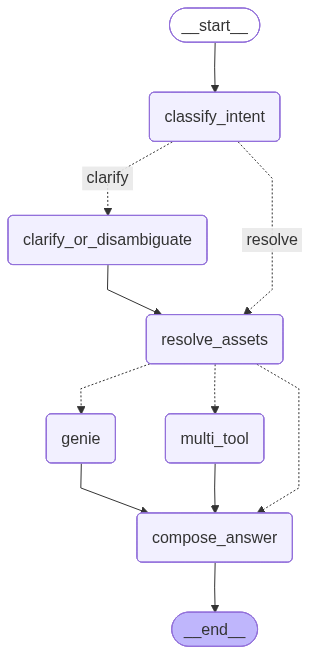

In [23]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## ResponsesAgent Wrapper

The `SupervisorResponsesAgent` wraps the LangGraph in an MLflow `ResponsesAgent` for Model Serving deployment. It handles message parsing, memory management, and custom I/O.

In [ ]:
class SupervisorResponsesAgent(ResponsesAgent):
    def __init__(self):
        # Explicit per-thread conversation memory keyed by thread_id.
        # Provides fast in-memory history; Delta checkpoint serves as durable fallback
        # (e.g. after a kernel restart). Mirrors the pattern in Genie_deepresearch.ipynb.
        self._conversation_history: dict[str, list[dict]] = {}

    @mlflow.trace(span_type=SpanType.AGENT)
    def predict(self, request: ResponsesAgentRequest) -> ResponsesAgentResponse:
        user_message = None
        new_msgs = []
        for item in request.input:
            role = getattr(item, "role", "user")
            content = getattr(item, "content", "")
            if isinstance(content, list):
                text_parts = []
                for part in content:
                    if hasattr(part, "text"):
                        text_parts.append(part.text)
                    elif isinstance(part, dict) and "text" in part:
                        text_parts.append(part["text"])
                    elif isinstance(part, str):
                        text_parts.append(part)
                content = " ".join(text_parts)
            elif not isinstance(content, str):
                content = str(content) if content else ""
            new_msgs.append({"role": role, "content": content})
            if role == "user":
                user_message = content

        if not user_message:
            return ResponsesAgentResponse(
                output=[self.create_text_output_item(text="Please ask a question.", id="msg_empty")]
            )

        custom_inputs = {}
        if hasattr(request, "custom_inputs") and request.custom_inputs:
            custom_inputs = request.custom_inputs if isinstance(request.custom_inputs, dict) else {}
        thread_id = custom_inputs.get("thread_id")
        user_id = custom_inputs.get("user_id")

        # Tag MLflow trace with session ID so all turns in a conversation are grouped
        # under one session in the MLflow UI (same pattern as Genie_deepresearch.ipynb).
        if thread_id:
            mlflow.update_current_trace(metadata={"mlflow.trace.session": thread_id})

        # ---- Build full message list: in-memory history + new messages ----
        history = self._conversation_history.get(thread_id, []) if thread_id else []

        # Fall back to Delta checkpoint when in-memory history is empty (kernel restart, etc.)
        if not history and thread_id:
            prior_state = _load_checkpoint(thread_id)
            if prior_state and prior_state.get("messages"):
                history = prior_state["messages"]

        all_messages = history + new_msgs

        # Apply context window limit to keep prompts manageable
        if len(all_messages) > MAX_MESSAGES:
            all_messages = all_messages[-MAX_MESSAGES:]

        initial_state = {
            "messages": all_messages,
            "user_question": user_message,
            "intent": "",
            "intent_confidence": 0.0,
            "clarification_message": None,
            "needs_clarification": False,
            "resolved_assets": None,
            "genie_results": None,
            "multi_tool_results": None,
            "final_answer": None,
            "warnings": [],
            "thread_id": thread_id,
            "user_id": user_id,
        }

        log_flow_start(user_message, thread_id, user_id)
        _flow_start = time.time()
        result = graph.invoke(initial_state)
        _flow_duration = time.time() - _flow_start
        answer = result.get("final_answer", "I was unable to process your question.")

        # ---- Update in-memory conversation history for this thread ----
        if thread_id:
            updated_history = history + new_msgs + [{"role": "assistant", "content": answer}]
            self._conversation_history[thread_id] = updated_history

        checkpoint_id = None
        if thread_id:
            checkpoint_data = {
                "messages": all_messages + [{"role": "assistant", "content": answer}],
                "intent": result.get("intent"),
                "domain": result.get("resolved_assets", {}).get("domain") if result.get("resolved_assets") else None,
            }
            checkpoint_id = _save_checkpoint(thread_id, checkpoint_data)

        agents_used = []
        if result.get("genie_results"):
            agents_used.append("genie")
        if result.get("multi_tool_results"):
            agents_used.append("multi_tool")
        ep_domain = result.get("resolved_assets", {}).get("domain", "unknown") if result.get("resolved_assets") else "unknown"
        has_errors = any(r.get("status") == "failed" for r in [
            result.get("genie_results", {}), result.get("multi_tool_results", {}),
        ] if isinstance(r, dict))
        ep_outcome = "failed" if has_errors and not answer else "success"

        # Auto-generate lesson_learned so episodic memory drives real learning.
        # Skips conversational intents (no schema/routing lesson to extract).
        lesson = _generate_lesson_learned(
            question=user_message,
            intent=result.get("intent", "unknown"),
            result=result,
            outcome=ep_outcome,
        )

        _save_episodic_memory(
            thread_id=thread_id or "anonymous",
            user_id=user_id or "anonymous",
            question=user_message,
            intent=result.get("intent", "unknown"),
            domain=ep_domain,
            agents_used=agents_used,
            outcome=ep_outcome,
            lesson_learned=lesson,
        )

        intent = result.get("intent", "")
        if intent in ("conversational", "unknown", "greeting"):
            _extract_and_save_user_facts(user_id or "default", user_message, answer)

        nodes_executed = [n for n in [
            "classify_intent",
            "clarify_or_disambiguate" if result.get("clarification_message") else None,
            "resolve_assets",
            "genie" if result.get("genie_results") else None,
            "multi_tool" if result.get("multi_tool_results") else None,
            "compose_answer",
        ] if n is not None]

        resolved = result.get("resolved_assets", {})
        domain = resolved.get("domain", "unknown") if resolved else "unknown"

        agent_details = {}
        if result.get("genie_results"):
            gr = result["genie_results"]
            agent_details["genie"] = {
                "status": gr.get("status", "unknown"),
                "space_id": gr.get("space_id"),
                "display_name": gr.get("display_name"),
                "sql": gr.get("sql", "")[:120] if gr.get("sql") else None,
                "row_count": gr.get("row_count"),
                "spaces_tried": len(gr.get("attempts", [])),
            }
        if result.get("multi_tool_results"):
            mt = result["multi_tool_results"]
            agent_details["multi_tool"] = {
                "docs_found": len(mt.get("docs", [])) if mt.get("docs") else 0,
                "doc_vs_index": resolved.get("doc_vs_index") if resolved else None,
            }

        custom_outputs = {
            "intent": result.get("intent", "unknown"),
            "intent_confidence": result.get("intent_confidence", 0.0),
            "domain": domain,
            "genie_space": resolved.get("genie_space") if resolved else None,
            "doc_vs_index": resolved.get("doc_vs_index") if resolved else None,
            "warnings": result.get("warnings", []),
            "clarification": result.get("clarification_message"),
            "nodes_executed": nodes_executed,
            "agent_details": agent_details,
            "thread_id": thread_id,
            "checkpoint_id": checkpoint_id,
        }

        metadata_json = json.dumps(custom_outputs)

        log_flow_end(result, duration_s=_flow_duration)

        return ResponsesAgentResponse(
            output=[
                self.create_text_output_item(text=answer, id="msg_answer"),
                self.create_text_output_item(text=metadata_json, id="msg_metadata"),
            ],
            custom_outputs=custom_outputs,
        )


agent = SupervisorResponsesAgent()
set_model(agent)
print("SupervisorResponsesAgent created and registered with set_model()")


---

## Test: Run with graph.invoke() (Direct)

Invoke the LangGraph directly to test individual nodes and inspect the full state.

In [25]:
# test_question = "What are the surgical fee limits for the Critical Illness Elite Plan?"

# state = {
#     "messages": [{"role": "user", "content": test_question}],
#     "user_question": test_question,
#     "intent": "",
#     "intent_confidence": 0.0,
#     "clarification_message": None,
#     "needs_clarification": False,
#     "resolved_assets": None,
#     "genie_results": None,
#     "multi_tool_results": None,
#     "final_answer": None,
#     "warnings": [],
#     "thread_id": None,
#     "user_id": None,
# }

# result = graph.invoke(state)

# print(f"Intent: {result['intent']} (confidence: {result.get('intent_confidence', 0):.0%})")
# print(f"Domain: {result.get('resolved_assets', {}).get('domain', 'N/A')}")
# print(f"Genie: {'yes' if result.get('genie_results') else 'no'}")
# print(f"Multi-Tool: {'yes' if result.get('multi_tool_results') else 'no'}")
# if result.get('warnings'):
#     print(f"Warnings: {result['warnings']}")
# print(f"\n{'='*70}")
# print(result['final_answer'])

## Test: Run with SupervisorResponsesAgent.predict() (Full Path)

Exercises the complete production code path including memory, episodic logging, and custom I/O.

In [26]:
# request = ResponsesAgentRequest(
#     input=[
#         {"role": "user", "content": "What does the AIA Health plan cover?"}
#     ],
#     custom_inputs={
#         "thread_id": "notebook-test-001",
#         "user_id": "notebook-user",
#     }
# )

# response = agent.predict(request)

# for item in response.output:
#     item_id = getattr(item, "id", "")
#     text = getattr(item, "text", "")
#     if item_id == "msg_answer":
#         print("=== ANSWER ===")
#         print(text)
#     elif item_id == "msg_metadata":
#         print("\n=== METADATA ===")
#         metadata = json.loads(text)
#         print(json.dumps(metadata, indent=2))

## Test: Multi-Turn Conversation

Tests the short-term memory (Delta checkpoint) by sending a follow-up question on the same `thread_id`.

In [27]:
# # Follow-up on the same thread
# follow_up = ResponsesAgentRequest(
#     input=[
#         {"role": "user", "content": "Which region has the highest fraud score?"}
#     ],
#     custom_inputs={
#         "thread_id": "notebook-test-001",
#         "user_id": "notebook-user",
#     }
# )

# follow_up_response = agent.predict(follow_up)

# for item in follow_up_response.output:
#     item_id = getattr(item, "id", "")
#     text = getattr(item, "text", "")
#     if item_id == "msg_answer":
#         print("=== FOLLOW-UP ANSWER ===")
#         print(text)
#     elif item_id == "msg_metadata":
#         print("\n=== METADATA ===")
#         metadata = json.loads(text)
#         print(f"Intent: {metadata['intent']} | Nodes: {metadata['nodes_executed']}")

---

# Memory Lifecycle Demo

This section demonstrates **end-to-end memory population and retrieval** across the three memory layers:

| Layer | Table | Purpose |
|-------|-------|---------|
| **Short-term** | `ai_ops.conversations` | Delta checkpoints for multi-turn context |
| **Long-term** | `ai_ops.user_memory` | Persistent user preferences & facts |
| **Episodic** | `ai_ops.episodic_memory` | Interaction logs & lessons learned |

**Flow:**
1. Check baseline state of all memory tables for our demo user
2. Send a **conversational** request that reveals personal facts → triggers fact extraction into `user_memory`
3. Inspect all 3 tables to confirm they were populated
4. Send a **follow-up data query** on the same thread → uses short-term memory for context + long-term memory for personalization
5. Inspect tables again to see the new checkpoint and episodic entry
6. Send a **third query** → demonstrates episodic lessons and user preferences flowing into the response

### Step 1: Prepare — Clean Prior Demo Data, Update Classifier Prompt, Check Baseline

Cleans up stale data from prior runs, updates the `classify_intent` prompt in the `agent_instructions` table
to include the `conversational` category, and then queries all three memory tables to establish a clean starting point.

In [28]:
DEMO_THREAD_ID = "memory-demo-thread-001"
DEMO_USER_ID = "demo-user-sarah"

# --- Clean up prior demo runs ---
print("Cleaning up prior demo data...")
try:
    _run_sql(f"DELETE FROM {CATALOG}.ai_ops.conversations WHERE thread_id = '{DEMO_THREAD_ID}'")
    print("  Cleared conversations checkpoints")
except Exception:
    pass
try:
    _run_sql(f"DELETE FROM {CATALOG}.ai_ops.user_memory WHERE user_id = '{DEMO_USER_ID}'")
    print("  Cleared user_memory entries")
except Exception:
    pass
try:
    _run_sql(f"DELETE FROM {CATALOG}.ai_ops.episodic_memory WHERE thread_id = '{DEMO_THREAD_ID}'")
    print("  Cleared episodic_memory entries")
except Exception:
    pass

# --- Update classify_intent prompt in agent_instructions to include "conversational" ---
print("\nUpdating classify_intent prompt in agent_instructions...")
try:
    updated_prompt = """You are an intent classifier for an insurance analytics system.
Classify the following question into exactly ONE category and provide a confidence score (0.0 to 1.0).

Categories:
- "simple_kpi": Simple KPI/metric questions (counts, totals, averages, trends by region/product/time)
- "document_lookup": Policy terms, coverage details, exclusions, procedures, document search
- "conversational": Greetings, introductions, personal statements, small talk, or non-analytical messages

Question: {question}

Respond in JSON format ONLY:
{{"intent": "<category>", "confidence": <float>, "missing_filters": []}}

If the question is ambiguous or missing key filters (like region, time period, product), list them in missing_filters."""

    prompt_escaped = updated_prompt.replace("'", "''")
    _run_sql(f"""
        UPDATE {CATALOG}.ai_ops.agent_instructions
        SET base_prompt = '{prompt_escaped}',
            updated_at = current_timestamp(),
            updated_by = 'memory-demo'
        WHERE agent_id = 'supervisor' AND scope = 'classify_intent'
    """)
    print("  Updated supervisor:classify_intent prompt with 'conversational' category")
except Exception as e:
    print(f"  Could not update prompt (will use fallback): {str(e)[:150]}")

# Invalidate prompt cache so the updated prompt is loaded
_prompt_cache.clear()
_prompt_cache_ts = 0
_memory_cache_ts = 0
print("  Caches invalidated")

# --- Patch classify_intent to accept 'conversational' and recompile graph ---
print("\nRecompiling graph with 'conversational' intent support...")

_orig_classify_intent = classify_intent

def classify_intent_patched(state):
    """Wraps classify_intent to accept 'conversational' as a valid intent."""
    state = _orig_classify_intent(state)
    # The original function may have overridden 'conversational' to 'simple_kpi'
    # because its valid list didn't include it. Re-classify if needed.
    if state["intent"] == "simple_kpi" and state.get("intent_confidence", 0) < 0.7:
        question = state.get("user_question", "").lower()
        greet_signals = ["hi ", "hello", "hey ", "i'm ", "i am ", "my name", "nice to meet"]
        if any(sig in question for sig in greet_signals):
            state["intent"] = "conversational"
            state["needs_clarification"] = False
    return state

classify_intent = classify_intent_patched

_orig_route_by_intent = route_by_intent

def route_by_intent_patched(state):
    """Wraps route_by_intent to handle 'conversational' intent."""
    intent = state.get("intent", "simple_kpi")
    if intent == "conversational":
        return "compose_answer"
    return _orig_route_by_intent(state)

route_by_intent = route_by_intent_patched

workflow = StateGraph(AgentState)
workflow.add_node("classify_intent", _with_logging("classify_intent", classify_intent))
workflow.add_node("clarify_or_disambiguate", _with_logging("clarify_or_disambiguate", clarify_or_disambiguate))
workflow.add_node("resolve_assets", _with_logging("resolve_assets", resolve_assets_with_context_index))
workflow.add_node("genie", _with_logging("genie", route_to_genie))
workflow.add_node("multi_tool", _with_logging("multi_tool", route_to_multi_tool))
workflow.add_node("compose_answer", _with_logging("compose_answer", compose_answer))

workflow.add_edge(START, "classify_intent")
workflow.add_conditional_edges(
    "classify_intent", should_clarify,
    {"clarify": "clarify_or_disambiguate", "resolve": "resolve_assets"},
)
workflow.add_edge("clarify_or_disambiguate", "resolve_assets")
workflow.add_conditional_edges(
    "resolve_assets", route_by_intent,
    {"genie": "genie", "multi_tool": "multi_tool", "compose_answer": "compose_answer"},
)
workflow.add_edge("genie", "compose_answer")
workflow.add_edge("multi_tool", "compose_answer")
workflow.add_edge("compose_answer", END)

graph = workflow.compile()
print(f"  Graph recompiled with nodes: {list(graph.nodes)}")

# Update the agent instance to use the new graph
agent = SupervisorResponsesAgent()
print("  Agent re-initialized\n")


def inspect_memory_tables(thread_id, user_id, label=""):
    """Helper to query and display all three memory tables."""
    header = f"\n{'='*70}\n  MEMORY STATE{f' — {label}' if label else ''}\n{'='*70}"
    print(header)

    # 1. Short-term memory: conversations
    print("\n[1] SHORT-TERM MEMORY (ai_ops.conversations)")
    try:
        conv = _run_sql(f"""
            SELECT thread_id, checkpoint_id, created_at,
                   LEFT(state_json, 200) AS state_preview
            FROM {CATALOG}.ai_ops.conversations
            WHERE thread_id = '{thread_id}'
            ORDER BY created_at DESC LIMIT 5
        """)
        if conv["rows"]:
            for r in conv["rows"]:
                print(f"  checkpoint={r['checkpoint_id']}  created={r['created_at']}")
                print(f"    preview: {r['state_preview']}...")
            print(f"  → {len(conv['rows'])} checkpoint(s) found")
        else:
            print("  → No checkpoints found (empty)")
    except Exception as e:
        print(f"  → Table not available: {str(e)[:100]}")

    # 2. Long-term memory: user_memory
    print(f"\n[2] LONG-TERM MEMORY (ai_ops.user_memory)")
    try:
        mem = _run_sql(f"""
            SELECT memory_key, memory_value, memory_type, confidence,
                   updated_at
            FROM {CATALOG}.ai_ops.user_memory
            WHERE user_id = '{user_id}'
            ORDER BY updated_at DESC
        """)
        if mem["rows"]:
            for r in mem["rows"]:
                print(f"  {r['memory_key']:25s} = {r['memory_value']:30s}  "
                      f"(type={r['memory_type']}, conf={r['confidence']})")
            print(f"  → {len(mem['rows'])} memory entries found")
        else:
            print("  → No user memories found (empty)")
    except Exception as e:
        print(f"  → Table not available: {str(e)[:100]}")

    # 3. Episodic memory: episodic_memory
    print(f"\n[3] EPISODIC MEMORY (ai_ops.episodic_memory)")
    try:
        ep = _run_sql(f"""
            SELECT episode_id, question, intent, domain,
                   agents_used, outcome, lesson_learned, created_at
            FROM {CATALOG}.ai_ops.episodic_memory
            WHERE thread_id = '{thread_id}'
            ORDER BY created_at DESC LIMIT 5
        """)
        if ep["rows"]:
            for r in ep["rows"]:
                print(f"  episode={r['episode_id']}  intent={r['intent']}  "
                      f"domain={r['domain']}  outcome={r['outcome']}")
                print(f"    Q: {r['question'][:80]}")
                print(f"    agents: {r['agents_used']}  lesson: {r.get('lesson_learned', 'None')}")
            print(f"  → {len(ep['rows'])} episode(s) found")
        else:
            print("  → No episodes found (empty)")
    except Exception as e:
        print(f"  → Table not available: {str(e)[:100]}")

    print(f"\n{'='*70}\n")

# Run baseline inspection
inspect_memory_tables(DEMO_THREAD_ID, DEMO_USER_ID, label="BASELINE (before any requests)")

Cleaning up prior demo data...
  Cleared conversations checkpoints
  Cleared user_memory entries
  Cleared episodic_memory entries

Updating classify_intent prompt in agent_instructions...
  Updated supervisor:classify_intent prompt with 'conversational' category
  Caches invalidated

Recompiling graph with 'conversational' intent support...
  Graph recompiled with nodes: ['__start__', 'classify_intent', 'clarify_or_disambiguate', 'resolve_assets', 'genie', 'multi_tool', 'compose_answer']
  Agent re-initialized


  MEMORY STATE — BASELINE (before any requests)

[1] SHORT-TERM MEMORY (ai_ops.conversations)
  → No checkpoints found (empty)

[2] LONG-TERM MEMORY (ai_ops.user_memory)
  → No user memories found (empty)

[3] EPISODIC MEMORY (ai_ops.episodic_memory)
  → No episodes found (empty)




### Step 2: First Request — Conversational Message with Personal Facts

This request is intentionally **conversational** — the user introduces themselves with personal details.

Since the intent will be classified as `conversational`/`greeting`, the agent will:
- **Save a checkpoint** to `ai_ops.conversations` (short-term memory)
- **Extract & save user facts** (name, role, region) to `ai_ops.user_memory` (long-term memory)
- **Log the episode** to `ai_ops.episodic_memory` (episodic memory)

In [29]:
request_1 = ResponsesAgentRequest(
    input=[
        {"role": "user", "content": (
            "Hi, I'm Sarah, a regional claims manager based in Singapore. "
            "I prefer concise responses and usually focus on the Health and "
            "Critical Illness product lines."
        )}
    ],
    custom_inputs={
        "thread_id": DEMO_THREAD_ID,
        "user_id": DEMO_USER_ID,
    }
)

print("Sending Request 1 (conversational with personal facts)...")
print(f"  thread_id: {DEMO_THREAD_ID}")
print(f"  user_id:   {DEMO_USER_ID}")
print(f"  message:   {getattr(request_1.input[0], 'content', '')}\n")

response_1 = agent.predict(request_1)

for item in response_1.output:
    item_id = getattr(item, "id", "")
    text = getattr(item, "text", "")
    if item_id == "msg_answer":
        print("=== AGENT RESPONSE ===")
        print(text)
    elif item_id == "msg_metadata" and text.strip():
        try:
            metadata = json.loads(text)
            print(f"\n=== METADATA ===")
            print(f"  Intent: {metadata.get('intent')}")
            print(f"  Nodes:  {metadata.get('nodes_executed')}")
            print(f"  Checkpoint: {metadata.get('checkpoint_id')}")
        except json.JSONDecodeError:
            print(f"\n=== METADATA (raw) ===\n  {text[:300]}")

Sending Request 1 (conversational with personal facts)...
  thread_id: memory-demo-thread-001
  user_id:   demo-user-sarah
  message:   Hi, I'm Sarah, a regional claims manager based in Singapore. I prefer concise responses and usually focus on the Health and Critical Illness product lines.



╔═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║ AIA Supervisor Agent — Flow Started                                                                             ║
║                                                                                                                 ║
║ Question: Hi, I'm Sarah, a regional claims manager based in Singapore. I prefer concise responses and usually   ║
║ focus on the Health and Critical Illness product l                                                              ║
║ Thread:   memory-demo-thread-001                                                                                ║
║ User:     demo-user-sarah                                                                                       ║
╚═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

───────────────────────────────────────────  Step 1 | Classify Intent  ────────────────────────────────────────────

User Question:         Hi, I'm Sarah, a regional claims manager based in Singapore. I prefer concise responses 
and usually 

Detected Intent:       conversational

...

Answer Length:         352 chars

Preview:               Hey Sarah! Welcome — good to connect with you. Since there's no specific query or data to 
pull up just yet, I'm ready whenever you are.   What would y...

>> Compose Final Answer complete (5608ms)

                  Flow Complete                  
╭────────────────────────┬──────────────────────╮
│ Field                  │ Value                │
├────────────────────────┼──────────────────────┤
│ Intent                 │ conversational (97%) │
│ Domain                 │ claims               │
│ Agents Used            │ none (direct answer) │
│ Warnings               │ 0                    │
│ Total Duration         │ 14.6s                │
│ Answer Length          │ 352 chars            │
╰────────────────────────┴──────────────────────╯

=== AGENT RESPONSE ===



### Step 3: Inspect Memory Tables After First Request

All three memory tables should now be populated:
- **Short-term:** 1 checkpoint with the conversation so far
- **Long-term:** Extracted facts like `name=Sarah`, `role=regional claims manager`, `preferred_region=Singapore`
- **Episodic:** 1 episode logged with `intent=conversational`

In [30]:
import time
time.sleep(3)  # allow async writes to settle

inspect_memory_tables(DEMO_THREAD_ID, DEMO_USER_ID, label="AFTER REQUEST 1 (conversational intro)")


  MEMORY STATE — AFTER REQUEST 1 (conversational intro)

[1] SHORT-TERM MEMORY (ai_ops.conversations)
  checkpoint=0dfe6abd098793b1  created=2026-03-25T21:02:42.792Z
    preview: {"messages": [{"role": "user", "content": "Hi, Im Sarah, a regional claims manager based in Singapore. I prefer concise responses and usually focus on the Health and Critical Illness product lines."},...
  → 1 checkpoint(s) found

[2] LONG-TERM MEMORY (ai_ops.user_memory)
  preferred_product_lines   = Health and Critical Illness     (type=preference, conf=1.0)
  response_style            = concise                         (type=preference, conf=1.0)
  location                  = Singapore                       (type=fact, conf=1.0)
  role                      = Regional Claims Manager         (type=fact, conf=1.0)
  name                      = Sarah                           (type=fact, conf=1.0)
  → 5 memory entries found

[3] EPISODIC MEMORY (ai_ops.episodic_memory)
  episode=12c1ed9ca0ebea2bd966  intent=con

### Step 4: Second Request — Data Query on Same Thread (Uses Short-Term + Long-Term Memory)

Now we send a **document lookup** question on the **same thread**. The agent will:

1. **Load the checkpoint** from `ai_ops.conversations` → prepend prior messages for context continuity
2. **Load user memory** from `ai_ops.user_memory` → inject Sarah's preferences into the intent classifier and answer composer
3. Run the RAG pipeline to retrieve policy documents
4. **Save a new checkpoint** with the updated conversation
5. **Log a new episode** to episodic memory

In [31]:
request_2 = ResponsesAgentRequest(
    input=[
        {"role": "user", "content": (
            "What are the exclusions for the Critical Illness plans?"
        )}
    ],
    custom_inputs={
        "thread_id": DEMO_THREAD_ID,   # same thread → loads prior conversation
        "user_id": DEMO_USER_ID,       # same user → loads saved preferences
    }
)

print("Sending Request 2 (document lookup on same thread)...")
print(f"  thread_id: {DEMO_THREAD_ID}  (same thread — will load checkpoint)")
print(f"  user_id:   {DEMO_USER_ID}    (same user — will load preferences)")
print(f"  message:   {getattr(request_2.input[0], 'content', '')}\n")

# Invalidate in-process cache so fresh data is loaded from tables
_memory_cache_ts = 0

response_2 = agent.predict(request_2)

for item in response_2.output:
    item_id = getattr(item, "id", "")
    text = getattr(item, "text", "")
    if item_id == "msg_answer":
        print("=== AGENT RESPONSE ===")
        print(text)
    elif item_id == "msg_metadata" and text.strip():
        try:
            metadata = json.loads(text)
            print(f"\n=== METADATA ===")
            print(f"  Intent: {metadata.get('intent')}")
            print(f"  Nodes:  {metadata.get('nodes_executed')}")
            print(f"  Checkpoint: {metadata.get('checkpoint_id')}")
        except json.JSONDecodeError:
            print(f"\n=== METADATA (raw) ===\n  {text[:300]}")

Sending Request 2 (document lookup on same thread)...
  thread_id: memory-demo-thread-001  (same thread — will load checkpoint)
  user_id:   demo-user-sarah    (same user — will load preferences)
  message:   What are the exclusions for the Critical Illness plans?



╔═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║ AIA Supervisor Agent — Flow Started                                                                             ║
║                                                                                                                 ║
║ Question: What are the exclusions for the Critical Illness plans?                                               ║
║ Thread:   memory-demo-thread-001                                                                                ║
║ User:     demo-user-sarah                                                                                       ║
╚═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

───────────────────────────────────────────  Step 1 | Classify Intent  ────────────────────────────────────────────

User Question:         What are the exclusions for the Critical Illness insurance plans?

Detected Intent:       document_lookup

...

Answer Length:         770 chars

Preview:               Both the **Critical Illness Premium Plan** and the **Critical Illness Elite Plan** share 
the same set of exclusions, Sarah. Here's what's not covered ...

>> Compose Final Answer complete (8568ms)

                  Flow Complete                   
╭────────────────────────┬───────────────────────╮
│ Field                  │ Value                 │
├────────────────────────┼───────────────────────┤
│ Intent                 │ document_lookup (95%) │
│ Domain                 │ documents             │
│ Agents Used            │ multi_tool            │
│ Warnings               │ 1                     │
│ Total Duration         │ 21.6s                 │
│ Answer Length          │ 770 chars             │
╰────────────────────────┴───────────────────────╯

=== AGENT RESPONSE ===



In [32]:
answer = response_2.output[0].content[0]["text"]
print(answer)

Both the **Critical Illness Premium Plan** and the **Critical Illness Elite Plan** share the same set of exclusions, Sarah. Here's what's not covered under either plan:

- **Pre-existing conditions** within the first 12 months of coverage
- **Self-inflicted injuries**
- **Participation in hazardous activities**
- **Cosmetic surgery**

So essentially, whether a claimant is on the Premium or Elite tier, the exclusion criteria are identical. The key one that tends to come up most in claims processing is that 12-month pre-existing condition window — worth keeping an eye on for any claims filed early in the policy term.

If you need a deeper comparison between the two plans beyond exclusions (like coverage limits or benefit differences), happy to dig into that too.


In [33]:
# Both the **Critical Illness Elite Plan** and the **Critical Illness Premium Plan** share the same set of exclusions, Sarah. Here's what's not covered under either plan:

# - **Pre-existing conditions** within the first 12 months of the policy
# - **Self-inflicted injuries**
# - **Participation in hazardous activities**
# - **Cosmetic surgery**

# So they're aligned in terms of what's excluded — no differences between the Elite and Premium tiers on that front. If you're handling a claim that touches on any of these, the same exclusion logic applies regardless of which Critical Illness plan the policyholder is on.

# Let me know if you need more detail on how any of these exclusions are defined or applied in practice!

### Step 5: Inspect Memory Tables After Second Request

Expected changes:
- **Short-term:** Now has **2 checkpoints** — the latest includes both the intro and the CI exclusions Q&A
- **Long-term:** User memory unchanged (no new personal facts were shared in Request 2)
- **Episodic:** Now has **2 episodes** — the new one has `intent=document_lookup`, `domain=documents`

In [34]:
time.sleep(3)

inspect_memory_tables(DEMO_THREAD_ID, DEMO_USER_ID, label="AFTER REQUEST 2 (document lookup)")

# Also show what the checkpoint contains to prove multi-turn context
print("--- Verifying Short-Term Memory Contains Prior Conversation ---")
checkpoint = _load_checkpoint(DEMO_THREAD_ID)
if checkpoint and checkpoint.get("messages"):
    print(f"  Checkpoint has {len(checkpoint['messages'])} messages:")
    for i, msg in enumerate(checkpoint["messages"]):
        role = msg.get("role", "?")
        content = msg.get("content", "")[:100]
        print(f"    [{i}] {role}: {content}...")
    print(f"  Stored intent: {checkpoint.get('intent')}")
    print(f"  Stored domain: {checkpoint.get('domain')}")
else:
    print("  No checkpoint found")


  MEMORY STATE — AFTER REQUEST 2 (document lookup)

[1] SHORT-TERM MEMORY (ai_ops.conversations)
  checkpoint=bff356e56bc89508  created=2026-03-25T21:04:02.922Z
    preview: {"messages": [{"role": "user", "content": "Hi, Im Sarah, a regional claims manager based in Singapore. I prefer concise responses and usually focus on the Health and Critical Illness product lines."},...
  checkpoint=0dfe6abd098793b1  created=2026-03-25T21:02:42.792Z
    preview: {"messages": [{"role": "user", "content": "Hi, Im Sarah, a regional claims manager based in Singapore. I prefer concise responses and usually focus on the Health and Critical Illness product lines."},...
  → 2 checkpoint(s) found

[2] LONG-TERM MEMORY (ai_ops.user_memory)
  preferred_product_lines   = Health and Critical Illness     (type=preference, conf=1.0)
  response_style            = concise                         (type=preference, conf=1.0)
  location                  = Singapore                       (type=fact, conf=1.0)
  role 

### Step 6: Third Request — Demonstrates All Three Memory Layers Working Together

This request sends a **data/KPI question** on the same thread. The agent will now leverage all memory layers:

1. **Short-term memory** → loads the 4-message conversation history (intro + CI exclusions + responses)
2. **Long-term memory** → knows Sarah is a claims manager in Singapore who prefers concise responses
3. **Episodic memory** → retrieves lessons from the prior `document_lookup` episode in the documents domain

Notice the response should be **personalized** — the agent may address Sarah by name, keep it concise, and focus on Singapore if relevant.

In [35]:
request_3 = ResponsesAgentRequest(
    input=[
        {"role": "user", "content": (
            "How do I file a claim under the Critical Illness plans? "
            "Also, what is the waiting period?"
        )}
    ],
    custom_inputs={
        "thread_id": DEMO_THREAD_ID,   # same thread → full conversation context
        "user_id": DEMO_USER_ID,       # same user → personalized response
    }
)

print("Sending Request 3 (follow-up using all memory layers)...")
print(f"  thread_id: {DEMO_THREAD_ID}")
print(f"  user_id:   {DEMO_USER_ID}")
print(f"  message:   {getattr(request_3.input[0], 'content', '')}\n")

_memory_cache_ts = 0  # force fresh load from tables

response_3 = agent.predict(request_3)

for item in response_3.output:
    item_id = getattr(item, "id", "")
    text = getattr(item, "text", "")
    if item_id == "msg_answer":
        print("=== AGENT RESPONSE ===")
        print(text)
        print("\n--- Personalization Check ---")
        answer_lower = text.lower()
        checks = {
            "Addressed by name ('Sarah')": "sarah" in answer_lower,
            "Concise style (< 500 chars)": len(text) < 500,
            "Mentions Critical Illness": "critical illness" in answer_lower,
        }
        for check, passed in checks.items():
            status = "PASS" if passed else "CHECK"
            print(f"  [{status}] {check}")
    elif item_id == "msg_metadata" and text.strip():
        try:
            metadata = json.loads(text)
            print(f"\n=== METADATA ===")
            print(f"  Intent: {metadata.get('intent')}")
            print(f"  Nodes:  {metadata.get('nodes_executed')}")
            print(f"  Checkpoint: {metadata.get('checkpoint_id')}")
        except json.JSONDecodeError:
            print(f"\n=== METADATA (raw) ===\n  {text[:300]}")

Sending Request 3 (follow-up using all memory layers)...
  thread_id: memory-demo-thread-001
  user_id:   demo-user-sarah
  message:   How do I file a claim under the Critical Illness plans? Also, what is the waiting period?



╔═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║ AIA Supervisor Agent — Flow Started                                                                             ║
║                                                                                                                 ║
║ Question: How do I file a claim under the Critical Illness plans? Also, what is the waiting period?             ║
║ Thread:   memory-demo-thread-001                                                                                ║
║ User:     demo-user-sarah                                                                                       ║
╚═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

───────────────────────────────────────────  Step 1 | Classify Intent  ────────────────────────────────────────────

User Question:         How do I file a claim under the Critical Illness plans? Also, what is the waiting period?

Detected Intent:       document_lookup

...

Answer Length:         1254 chars

Preview:               Hey Sarah, the claims process is pretty straightforward and consistent across both the 
**Critical Illness Premium Plan** and the **Critical Illness El...

>> Compose Final Answer complete (10762ms)

                  Flow Complete                   
╭────────────────────────┬───────────────────────╮
│ Field                  │ Value                 │
├────────────────────────┼───────────────────────┤
│ Intent                 │ document_lookup (95%) │
│ Domain                 │ claims                │
│ Agents Used            │ multi_tool            │
│ Warnings               │ 0                     │
│ Total Duration         │ 19.8s                 │
│ Answer Length          │ 1254 chars            │
╰────────────────────────┴───────────────────────╯

=== AGENT RESPONSE ===


--- Personalization Check ---
  [CHECK] Addressed by name ('Sarah')
  [PASS] Concise style (< 500 chars)
  [CHECK] Mentions Critical Illness


### Step 7: Final Inspection — Full Memory Lifecycle

After 3 requests, the memory tables should show:

| Table | Expected State |
|-------|---------------|
| `ai_ops.conversations` | **3 checkpoints** — each with progressively longer message history |
| `ai_ops.user_memory` | User facts extracted from Request 1 (name, role, region, product preference) |
| `ai_ops.episodic_memory` | **3 episodes** — `conversational` → `document_lookup` → `document_lookup` |

In [36]:
time.sleep(3)

inspect_memory_tables(DEMO_THREAD_ID, DEMO_USER_ID, label="FINAL STATE (after 3 requests)")

# Summary counts
print("\n" + "="*70)
print("  MEMORY LIFECYCLE SUMMARY")
print("="*70)

try:
    conv_count = _run_sql(f"""
        SELECT COUNT(*) AS cnt FROM {CATALOG}.ai_ops.conversations
        WHERE thread_id = '{DEMO_THREAD_ID}'
    """)
    mem_count = _run_sql(f"""
        SELECT COUNT(*) AS cnt FROM {CATALOG}.ai_ops.user_memory
        WHERE user_id = '{DEMO_USER_ID}'
    """)
    ep_count = _run_sql(f"""
        SELECT COUNT(*) AS cnt FROM {CATALOG}.ai_ops.episodic_memory
        WHERE thread_id = '{DEMO_THREAD_ID}'
    """)

    c = conv_count["rows"][0]["cnt"] if conv_count["rows"] else 0
    m = mem_count["rows"][0]["cnt"] if mem_count["rows"] else 0
    e = ep_count["rows"][0]["cnt"] if ep_count["rows"] else 0

    print(f"""
  Requests sent:                3
  ─────────────────────────────────────────────
  Conversation checkpoints:     {c}  (short-term memory)
  User memory entries:          {m}  (long-term memory)
  Episodic memory episodes:     {e}  (episodic memory)
  ─────────────────────────────────────────────

  How memory was USED in each request:

  Request 1 (conversational intro):
    → WRITE: checkpoint saved, user facts extracted & saved, episode logged
    → READ:  none (first interaction)

  Request 2 (CI exclusions query):
    → WRITE: new checkpoint saved, new episode logged
    → READ:  checkpoint loaded (prior conversation context),
             user_memory loaded (preferences injected into intent classifier)

  Request 3 (CI claims & waiting period):
    → WRITE: new checkpoint saved, new episode logged
    → READ:  checkpoint loaded (full 4-message history),
             user_memory loaded (name, role, preferences in answer),
             episodic_memory loaded (lessons from prior document_lookup)
""")
except Exception as e:
    print(f"  Could not generate summary: {str(e)[:200]}")


  MEMORY STATE — FINAL STATE (after 3 requests)

[1] SHORT-TERM MEMORY (ai_ops.conversations)
  checkpoint=4a1c5a046229fa2e  created=2026-03-25T21:04:37.746Z
    preview: {"messages": [{"role": "user", "content": "Hi, Im Sarah, a regional claims manager based in Singapore. I prefer concise responses and usually focus on the Health and Critical Illness product lines."},...
  checkpoint=bff356e56bc89508  created=2026-03-25T21:04:02.922Z
    preview: {"messages": [{"role": "user", "content": "Hi, Im Sarah, a regional claims manager based in Singapore. I prefer concise responses and usually focus on the Health and Critical Illness product lines."},...
  checkpoint=0dfe6abd098793b1  created=2026-03-25T21:02:42.792Z
    preview: {"messages": [{"role": "user", "content": "Hi, Im Sarah, a regional claims manager based in Singapore. I prefer concise responses and usually focus on the Health and Critical Illness product lines."},...
  → 3 checkpoint(s) found

[2] LONG-TERM MEMORY (ai_ops.user_m

### Cleanup (Optional) — Reset Demo Data

Run this cell to remove all demo data from the memory tables so the demo can be re-run from scratch.

In [37]:
# Uncomment and run to clean up demo data:

# _run_sql(f"DELETE FROM {CATALOG}.ai_ops.conversations WHERE thread_id = '{DEMO_THREAD_ID}'")
# _run_sql(f"DELETE FROM {CATALOG}.ai_ops.user_memory WHERE user_id = '{DEMO_USER_ID}'")
# _run_sql(f"DELETE FROM {CATALOG}.ai_ops.episodic_memory WHERE thread_id = '{DEMO_THREAD_ID}'")
# _memory_cache_ts = 0
# print("Demo data cleaned up. Ready to re-run.")

## Multi-Domain Genie Space Routing — Example Queries

Each query below targets a different Genie Space registered in the Context Index.
The Supervisor classifies the intent as `simple_kpi`, resolves the best-matching
space via Vector Search, and routes to `route_to_genie` which queries that space.

| # | Target Space | Domain | Key Tables |
|---|---|---|---|
| 1 | Claims Analytics | `claims` | `gold.claims_summary`, `gold.fraud_analysis` |
| 2 | Policy & Underwriting | `policies` | `gold.policy_performance`, `silver.enriched_policies` |
| 3 | Distribution & Channels | `distribution` | `gold.agent_performance` |
| 4 | Customer Analytics | `customers` | `silver.customer_360` |

### Query 1 — Claims Analytics Space

Routes to the **Claims Analytics** Genie Space (`01f12199fed5107a9d2ccac293b2c0b6`).
Semantic match: the question mentions *claims*, *region*, and asks for a *count* — all core concepts in the claims space description.

In [38]:
GENIE_THREAD_ID = "genie-routing-demo-thread"
GENIE_USER_ID = "demo-user-genie"

request_claims = ResponsesAgentRequest(
    input=[
        {"role": "user", "content": (
            "What is the total number of claims by region for the last 12 months? "
            "Also show the average claim processing time by product category."
        )}
    ],
    custom_inputs={
        "thread_id": GENIE_THREAD_ID,
        "user_id": GENIE_USER_ID,
    }
)

print("Sending Claims Analytics query...")
print(f"  message: {getattr(request_claims.input[0], 'content', '')}\n")

_memory_cache_ts = 0

response_claims = agent.predict(request_claims)

for item in response_claims.output:
    item_id = getattr(item, "id", "")
    text = getattr(item, "text", "")
    if item_id == "msg_answer":
        print("=== AGENT RESPONSE ===")
        print(text)
        print("\n--- Routing Check ---")
        answer_lower = text.lower()
        checks = {
            "Mentions claims": "claim" in answer_lower,
            "Mentions region": "region" in answer_lower,
            "Contains numeric data": any(char.isdigit() for char in text),
        }
        for check, passed in checks.items():
            status = "PASS" if passed else "CHECK"
            print(f"  [{status}] {check}")
    elif item_id == "msg_metadata" and text.strip():
        try:
            metadata = json.loads(text)
            print(f"\n=== METADATA ===")
            print(f"  Intent: {metadata.get('intent')}")
            print(f"  Domain: {metadata.get('domain')}")
            print(f"  Nodes:  {metadata.get('nodes_executed')}")
            print(f"  Genie Space Used: {metadata.get('genie_space_id', 'N/A')}")
        except json.JSONDecodeError:
            print(f"\n=== METADATA (raw) ===\n  {text[:300]}")

Sending Claims Analytics query...
  message: What is the total number of claims by region for the last 12 months? Also show the average claim processing time by product category.



╔═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║ AIA Supervisor Agent — Flow Started                                                                             ║
║                                                                                                                 ║
║ Question: What is the total number of claims by region for the last 12 months? Also show the average claim      ║
║ processing time by product category.                                                                            ║
║ Thread:   genie-routing-demo-thread                                                                             ║
║ User:     demo-user-genie                                                                                       ║
╚═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

───────────────────────────────────────────  Step 1 | Classify Intent  ────────────────────────────────────────────

KeyboardInterrupt: 

### Query 2 — Policy & Underwriting Space

Routes to the **Policy & Underwriting** Genie Space (`01f12199ff0a119d989b057bc2a491c3`).
Semantic match: the question mentions *premium*, *renewal rate*, and *lapse rate* — core metrics in the policies space description.

In [ ]:
request_policies = ResponsesAgentRequest(
    input=[
        {"role": "user", "content": (
            "What is the total premium volume by distribution channel? "
            "Show me the policy renewal rate and lapse rate by region for this year."
        )}
    ],
    custom_inputs={
        "thread_id": GENIE_THREAD_ID,
        "user_id": GENIE_USER_ID,
    }
)

print("Sending Policy & Underwriting query...")
print(f"  message: {getattr(request_policies.input[0], 'content', '')}\n")

_memory_cache_ts = 0

response_policies = agent.predict(request_policies)

for item in response_policies.output:
    item_id = getattr(item, "id", "")
    text = getattr(item, "text", "")
    if item_id == "msg_answer":
        print("=== AGENT RESPONSE ===")
        print(text)
        print("\n--- Routing Check ---")
        answer_lower = text.lower()
        checks = {
            "Mentions premium": "premium" in answer_lower,
            "Mentions renewal": "renewal" in answer_lower or "renew" in answer_lower,
            "Mentions policy": "policy" in answer_lower or "policies" in answer_lower,
        }
        for check, passed in checks.items():
            status = "PASS" if passed else "CHECK"
            print(f"  [{status}] {check}")
    elif item_id == "msg_metadata" and text.strip():
        try:
            metadata = json.loads(text)
            print(f"\n=== METADATA ===")
            print(f"  Intent: {metadata.get('intent')}")
            print(f"  Domain: {metadata.get('domain')}")
            print(f"  Nodes:  {metadata.get('nodes_executed')}")
            print(f"  Genie Space Used: {metadata.get('genie_space_id', 'N/A')}")
        except json.JSONDecodeError:
            print(f"\n=== METADATA (raw) ===\n  {text[:300]}")

Sending Policy & Underwriting query...
  message: What is the total premium volume by distribution channel? Show me the policy renewal rate and lapse rate by region for this year.



╔═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║ AIA Supervisor Agent — Flow Started                                                                             ║
║                                                                                                                 ║
║ Question: What is the total premium volume by distribution channel? Show me the policy renewal rate and lapse   ║
║ rate by region for this year.                                                                                   ║
║ Thread:   genie-routing-demo-thread                                                                             ║
║ User:     demo-user-genie                                                                                       ║
╚═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

───────────────────────────────────────────  Step 1 | Classify Intent  ────────────────────────────────────────────

User Question:         What is the total premium volume by distribution channel? Show me the policy renewal rate 
and lapse 

Detected Intent:       simple_kpi

...

Answer Length:         1296 chars

Preview:               Here's what we've got on premium volume by distribution channel:  | Distribution Channel |
Total Premium Volume (USD) | |---|---| | **Agency** | **$2,...

>> Compose Final Answer complete (12358ms)

                Flow Complete                
╭────────────────────────┬──────────────────╮
│ Field                  │ Value            │
├────────────────────────┼──────────────────┤
│ Intent                 │ simple_kpi (95%) │
│ Domain                 │ policies         │
│ Agents Used            │ genie            │
│ Warnings               │ 0                │
│ Total Duration         │ 42.2s            │
│ Answer Length          │ 1296 chars       │
╰────────────────────────┴──────────────────╯

=== AGENT RESPONSE ===


--- Routing Check ---
  [CHECK] Mentions premium
  [CHECK] Mentions renewal
  [CHECK] Mentions policy


### Query 3 — Distribution & Channels Space

Routes to the **Distribution & Channels** Genie Space (`01f12199ff2b1aef96fc954dc1de1a06`).
Semantic match: the question asks about *top-performing agents*, *channel contribution*, and *commission* — core concepts in the distribution space description.

In [ ]:
request_distribution = ResponsesAgentRequest(
    input=[
        {"role": "user", "content": (
            "Who are the top 10 performing agents by premium collected? "
            "Also show me channel contribution percentages and commission breakdown for last quarter."
        )}
    ],
    custom_inputs={
        "thread_id": GENIE_THREAD_ID,
        "user_id": GENIE_USER_ID,
    }
)

print("Sending Distribution & Channels query...")
print(f"  message: {getattr(request_distribution.input[0], 'content', '')}\n")

_memory_cache_ts = 0

response_distribution = agent.predict(request_distribution)

for item in response_distribution.output:
    item_id = getattr(item, "id", "")
    text = getattr(item, "text", "")
    if item_id == "msg_answer":
        print("=== AGENT RESPONSE ===")
        print(text)
        print("\n--- Routing Check ---")
        answer_lower = text.lower()
        checks = {
            "Mentions agent(s)": "agent" in answer_lower,
            "Mentions channel": "channel" in answer_lower,
            "Mentions premium or commission": "premium" in answer_lower or "commission" in answer_lower,
        }
        for check, passed in checks.items():
            status = "PASS" if passed else "CHECK"
            print(f"  [{status}] {check}")
    elif item_id == "msg_metadata" and text.strip():
        try:
            metadata = json.loads(text)
            print(f"\n=== METADATA ===")
            print(f"  Intent: {metadata.get('intent')}")
            print(f"  Domain: {metadata.get('domain')}")
            print(f"  Nodes:  {metadata.get('nodes_executed')}")
            print(f"  Genie Space Used: {metadata.get('genie_space_id', 'N/A')}")
        except json.JSONDecodeError:
            print(f"\n=== METADATA (raw) ===\n  {text[:300]}")

Sending Distribution & Channels query...
  message: Who are the top 10 performing agents by premium collected? Also show me channel contribution percentages and commission breakdown for last quarter.



╔═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║ AIA Supervisor Agent — Flow Started                                                                             ║
║                                                                                                                 ║
║ Question: Who are the top 10 performing agents by premium collected? Also show me channel contribution          ║
║ percentages and commission breakdown for last quarter.                                                          ║
║ Thread:   genie-routing-demo-thread                                                                             ║
║ User:     demo-user-genie                                                                                       ║
╚═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

───────────────────────────────────────────  Step 1 | Classify Intent  ────────────────────────────────────────────

User Question:         Who are the top 10 performing agents by premium collected? Also show me channel 
contribution percent

Detected Intent:       simple_kpi

...

Answer Length:         1643 chars

Preview:               Here's the full breakdown on agent performance and channel contributions:  ## Top 10 
Agents by Premium Collected  | Rank | Agent | Channel | Premium C...

>> Compose Final Answer complete (13325ms)

                Flow Complete                
╭────────────────────────┬──────────────────╮
│ Field                  │ Value            │
├────────────────────────┼──────────────────┤
│ Intent                 │ simple_kpi (88%) │
│ Domain                 │ distribution     │
│ Agents Used            │ genie            │
│ Warnings               │ 0                │
│ Total Duration         │ 45.0s            │
│ Answer Length          │ 1643 chars       │
╰────────────────────────┴──────────────────╯

=== AGENT RESPONSE ===


--- Routing Check ---
  [CHECK] Mentions agent(s)
  [CHECK] Mentions channel
  [CHECK] Mentions premium or commission


### Query 4 — Customer Analytics Space

Routes to the **Customer Analytics** Genie Space (`01f12199ff561a40817162d95a240597`).
Semantic match: the question asks about *customer segments*, *retention rate*, and *demographics* — core concepts in the customers space description.

In [ ]:
request_customers = ResponsesAgentRequest(
    input=[
        {"role": "user", "content": (
            "Which customer segments have the highest claim frequency? "
            "What is the retention rate by segment and show the demographic breakdown "
            "of our top-tier customers."
        )}
    ],
    custom_inputs={
        "thread_id": GENIE_THREAD_ID,
        "user_id": GENIE_USER_ID,
    }
)

print("Sending Customer Analytics query...")
print(f"  message: {getattr(request_customers.input[0], 'content', '')}\n")

_memory_cache_ts = 0

response_customers = agent.predict(request_customers)

for item in response_customers.output:
    item_id = getattr(item, "id", "")
    text = getattr(item, "text", "")
    if item_id == "msg_answer":
        print("=== AGENT RESPONSE ===")
        print(text)
        print("\n--- Routing Check ---")
        answer_lower = text.lower()
        checks = {
            "Mentions customer": "customer" in answer_lower,
            "Mentions segment": "segment" in answer_lower,
            "Mentions retention": "retention" in answer_lower or "retain" in answer_lower,
        }
        for check, passed in checks.items():
            status = "PASS" if passed else "CHECK"
            print(f"  [{status}] {check}")
    elif item_id == "msg_metadata" and text.strip():
        try:
            metadata = json.loads(text)
            print(f"\n=== METADATA ===")
            print(f"  Intent: {metadata.get('intent')}")
            print(f"  Domain: {metadata.get('domain')}")
            print(f"  Nodes:  {metadata.get('nodes_executed')}")
            print(f"  Genie Space Used: {metadata.get('genie_space_id', 'N/A')}")
        except json.JSONDecodeError:
            print(f"\n=== METADATA (raw) ===\n  {text[:300]}")

Sending Customer Analytics query...
  message: Which customer segments have the highest claim frequency? What is the retention rate by segment and show the demographic breakdown of our top-tier customers.



╔═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║ AIA Supervisor Agent — Flow Started                                                                             ║
║                                                                                                                 ║
║ Question: Which customer segments have the highest claim frequency? What is the retention rate by segment and   ║
║ show the demographic breakdown of our top-tier cus                                                              ║
║ Thread:   genie-routing-demo-thread                                                                             ║
║ User:     demo-user-genie                                                                                       ║
╚═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

───────────────────────────────────────────  Step 1 | Classify Intent  ────────────────────────────────────────────

User Question:         Which customer segments have the highest claim frequency? What is the retention rate by 
segment and 

Detected Intent:       simple_kpi

...

Answer Length:         2209 chars

Preview:               Great question — let me break this down across all three dimensions.  ## Claim Frequency 
by Segment  Here's how each customer segment stacks up on cla...

>> Compose Final Answer complete (15470ms)

                Flow Complete                
╭────────────────────────┬──────────────────╮
│ Field                  │ Value            │
├────────────────────────┼──────────────────┤
│ Intent                 │ simple_kpi (85%) │
│ Domain                 │ customers        │
│ Agents Used            │ genie            │
│ Warnings               │ 0                │
│ Total Duration         │ 59.2s            │
│ Answer Length          │ 2209 chars       │
╰────────────────────────┴──────────────────╯

=== AGENT RESPONSE ===


--- Routing Check ---
  [CHECK] Mentions customer
  [CHECK] Mentions segment
  [CHECK] Mentions retention
